# Aula 4 — Notebook 1

## Do protótipo a um workflow multiagente operacional

Nesta etapa, o projeto sai do nível de protótipo e passa a ser organizado como um workflow observável, com responsabilidades separadas e decisões rastreáveis.

A composição principal é feita por **quatro agentes**, coordenados por LangGraph:

1. agente de triagem;
2. agente investigador;
3. agente revisor;
4. agente planejador de ação.

A escolha por essa arquitetura não significa que seja necessariamente a escolha ideal para este cenário, mas ela permite observar, em momentos distintos, como o sistema decide, investiga, critica e planeja. Isso deixa o raciocínio mais transparente, mas também mostra o custo real da modularização: mais latência, mais chamadas, mais pontos de falha e mais complexidade de manutenção.

Ao longo do notebook, a comparação mais importante é esta: quando vale separar responsabilidades em vários agentes e quando um agente único, bem validado, já resolve o problema com menos custo operacional. No fim, compare esta abordagem com a alternativa de agente único em `target_project/incident_agent/app/single_agent_baseline.py`.


## 1. Por que LangGraph nesta etapa?

LangGraph é útil quando o problema deixa de ser apenas "gerar uma resposta" e passa a ser "orquestrar uma sequência de decisões com estados intermediários". Aqui, o workflow precisa guardar o que foi decidido em cada etapa, o que foi consultado, o que foi validado e quais caminhos foram tomados ou bloqueados.

Em termos práticos, o grafo funciona como uma representação explícita do processo:

- cada nó lê o estado atual;
- cada nó devolve apenas as alterações que produziu;
- o fluxo entre nós pode ser linear, condicional ou cíclico;
- regras determinísticas continuam fora do modelo;
- o LLM participa onde interpretação, síntese ou crítica realmente ajudam.

Essa separação é importante porque evita misturar duas coisas diferentes:

- **interpretação probabilística**, que é onde o modelo pode ajudar;
- **execução controlada**, que precisa continuar previsível e auditável.

O desenho do grafo segue essa lógica:

```text
triage_agent
     ↓
execute_tools
     ↓
investigation_agent
     ↓
deterministic_validation
     ↓
review_agent
  ↙      ↘
retry   action_planner_agent
            ↓
       policy_check
         ↙     ↘
 human_review  simulation
```

Lendo esse fluxo de cima para baixo, a intenção fica clara: primeiro o sistema interpreta o caso, depois coleta evidências, em seguida valida de forma independente e só então decide se pode propor uma ação ou se precisa recuar para revisão humana.


In [8]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
INCIDENT_AGENT_DIR = PROJECT_ROOT / "target_project" / "incident_agent"

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(INCIDENT_AGENT_DIR))

from shared.aula_4.langgraph_helpers import build_initial_state
from shared.aula_4.validation import validate_incident_input

## 2. O estado como contrato de execução

O estado não é uma memória interna escondida dentro de um objeto. Ele é um contrato explícito de execução: um dicionário estruturado, tipado por `WorkflowState`, que registra o que aconteceu em cada passo do workflow.

Pensar no estado como contrato ajuda por três motivos:

1. torna o comportamento reproduzível, porque cada etapa recebe exatamente o que precisa;
2. facilita depuração, porque qualquer decisão importante fica registrada;
3. permite testar cada nó isoladamente, sem precisar executar todo o grafo para entender um problema.

Os campos principais do estado representam as camadas do raciocínio do sistema:

- `incident`: a entrada original, preservada para auditoria;
- `triage`: o resultado da triagem inicial, com a leitura do problema e a decisão de rota;
- `selected_tools` e `search_queries`: as escolhas que podem ser executadas pelo código;
- `retrieved_evidence`: o material trazido pelas ferramentas;
- `investigation`: hipóteses, síntese e recomendações do agente investigador;
- `deterministic_validation`: verificações independentes do LLM;
- `review`: a avaliação crítica do agente revisor;
- `proposed_action`: a ação estruturada que será proposta ao final;
- `metrics` e `events`: rastreabilidade operacional e telemetria.

Esse formato é útil porque separa raciocínio, execução e observabilidade. Assim, o notebook não mostra apenas "o que respondeu", mas também "como chegou até ali".


In [9]:
incident_path = INCIDENT_AGENT_DIR / "data" / "incidents" / "incident_documented.json"
incident_payload = json.loads(incident_path.read_text(encoding="utf-8"))
incident = validate_incident_input(incident_payload)

initial_state = build_initial_state(incident)
initial_state


{'run_id': 'run_0fb780099288',
 'incident': {'description': 'O job orders_daily falhou após timeout na leitura da tabela raw_orders.',
  'severity': 'high',
  'title': 'Falha no pipeline de pedidos',
  'incident_id': 'INC-1001',
  'source': 'monitoring'},
 'selected_tools': [],
 'search_queries': [],
 'retrieved_evidence': [],
 'retry_count': 0,
 'status': 'created',
 'errors': [],
 'metrics': {'steps': {},
  'input_tokens': 0,
  'output_tokens': 0,
  'total_tokens': 0,
  'estimated_cost_usd': 0.0},
 'events': []}

## 3. Funções de domínio, agentes e adaptadores do framework

Uma decisão de arquitetura importante neste projeto é manter as regras de domínio separadas do framework. Isso reduz acoplamento e torna mais fácil entender o que é "regra do problema" e o que é "infraestrutura de orquestração".

As funções em `shared/aula_4` foram divididas justamente para isso:

- regras e validações que continuam válidas mesmo fora do LangGraph;
- funções de recuperação de informação que podem ser testadas sem o workflow completo;
- políticas de decisão que não dependem do modelo para existir;
- coleta de métricas e eventos para observabilidade.

Já as peças específicas de LangGraph ficam responsáveis pelo encaixe dessas partes no fluxo:

- criação do `StateGraph`;
- definição dos nós;
- configuração das arestas condicionais;
- compilação do workflow;
- invocação sequencial ou condicional das etapas.

Essa divisão evita uma armadilha comum em sistemas com LLM: deixar o modelo decidir tudo. Aqui, o agente de triagem sugere ferramentas, mas a execução real continua restrita a uma lista controlada. Em outras palavras, o modelo aponta caminhos; o código decide o que é permitido executar.


In [10]:
from shared.aula_4.retrieval import (
    AVAILABLE_TOOLS,
    execute_selected_tools,
    load_json_documents,
)

knowledge_dir = INCIDENT_AGENT_DIR / "data/knowledge"
documents = load_json_documents(knowledge_dir)

# Simulação da decisão que, no workflow real, é produzida pelo agente de triagem.
selected_tools = ["search_runbooks", "search_logs"]
search_queries = ["timeout raw_orders orders_daily"]

evidence = execute_selected_tools(selected_tools, search_queries, documents)
evidence


[{'evidence_id': 'RB-001',
  'source_type': 'runbook',
  'content': 'Verifique disponibilidade da origem, volume de dados e conexões abertas. Não reinicie automaticamente se houver risco de duplicação. Gere diagnóstico e solicite aprovação antes de reprocessar.',
  'relevance_reason': 'ferramenta=runbook; consulta=timeout raw_orders orders_daily; pontuação=1.000'},
 {'evidence_id': 'LOG-001',
  'source_type': 'log',
  'content': 'A leitura de raw_orders excedeu 300 segundos. A etapa de escrita não foi iniciada e não há registro de duplicação.',
  'relevance_reason': 'ferramenta=log; consulta=timeout raw_orders orders_daily; pontuação=1.000'}]

## 4. O grafo completo e as chamadas aos agentes

Cada agente é criado em `shared/aula_4/llm.py` com saída estruturada. Isso é importante porque reduz a ambiguidade do retorno do modelo e facilita validar o que foi produzido antes de seguir para a próxima etapa.

A chamada efetiva ao modelo acontece dentro de `invoke_structured_agent`, que é usada pelos nós:

- `triage_node`;
- `investigate_node`;
- `review_node`;
- `action_planner_node`.

A leitura correta do grafo é esta: LangGraph não "pensa" no lugar do agente. Ele controla a ordem, os desvios e as repetições. O raciocínio continua dentro do nó, mas o caminho do raciocínio fica sob controle do workflow.

Esse detalhe é fundamental para a disciplina operacional do sistema. As validações e políticas continuam fora do LLM porque uma resposta convincente não pode ter autoridade para ignorar regras. Se o modelo sugerir algo incompatível com o contrato, o código ainda precisa bloquear, revisar ou redirecionar a execução.


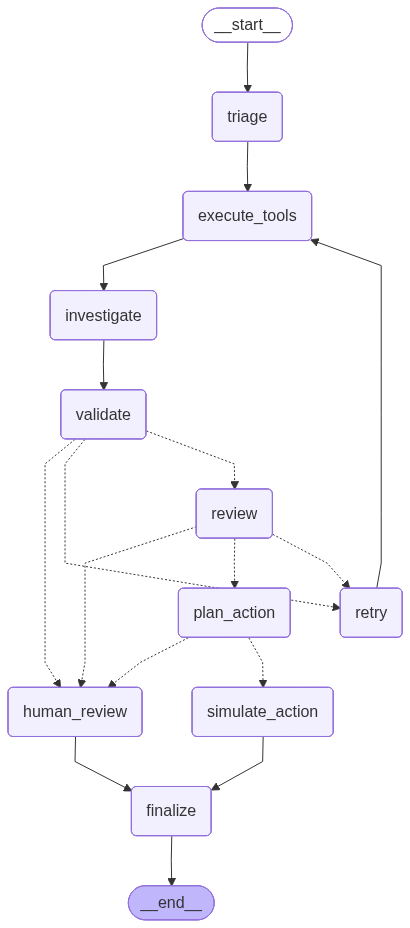

In [14]:
from shared.aula_4.config import get_settings
from app.workflow import build_workflow

# Esta célula exige uma OPENAI_API_KEY configurada no ambiente ou em target_project/incident_agent/.env.
settings = get_settings(INCIDENT_AGENT_DIR / ".env")
workflow = build_workflow(settings, knowledge_dir)
workflow

## 5. Executando o workflow

A execução real depende de uma chave válida do provedor configurado. Antes de ativar esta célula, copie `.env.example` para `.env` e defina `OPENAI_API_KEY`.

Nesta etapa, o interesse não é apenas "rodar o código". O objetivo é observar o comportamento do sistema como fluxo operacional. Durante a execução, vale acompanhar:

1. quais ferramentas a triagem selecionou e por quê;
2. quais evidências foram recuperadas e se elas realmente ajudam;
3. se o investigador sintetizou hipóteses coerentes com os dados;
4. se a validação determinística confirmou ou contradisse a leitura do modelo;
5. se o revisor aprovou o caminho ou forçou uma nova rodada;
6. se a política final permitiu simulação ou exigiu intervenção humana.

Essa leitura é mais importante do que o resultado final isolado. O valor do workflow está em tornar visível a cadeia de decisões, para que seja possível entender onde o processo ficou forte, onde ficou frágil e onde o custo operacional deixa de compensar.


In [15]:
from app.workflow import run_workflow

settings = get_settings(INCIDENT_AGENT_DIR / ".env")
result = run_workflow(incident, settings, knowledge_dir)
result

{'run_id': 'run_d7b9bffede99',
 'incident': {'description': 'O job orders_daily falhou após timeout na leitura da tabela raw_orders.',
  'severity': 'high',
  'title': 'Falha no pipeline de pedidos',
  'incident_id': 'INC-1001',
  'source': 'monitoring'},
 'triage': {'classification': 'Falha de pipeline de dados por timeout na leitura de tabela',
  'priority': 'high',
  'selected_tools': ['search_logs', 'search_runbooks'],
  'search_queries': ['timeout na leitura da tabela raw_orders',
   'job orders_daily falhou',
   'pipeline de pedidos falha timeout'],
  'rationale': 'O incidente envolve falha por timeout na leitura de uma tabela específica durante a execução de um job, o que sugere a necessidade de investigar logs para identificar a causa exata do timeout e consultar runbooks para procedimentos de resolução e prevenção. A busca em histórico de incidentes pode ser útil, mas inicialmente os logs e runbooks são mais críticos para diagnóstico e ação imediata.'},
 'selected_tools': ['se

## 6. Exercício orientado — multiagente ou agente único?

A comparação final deste notebook não é um teste de preferência estética. Ela serve para responder uma pergunta de engenharia: qual arquitetura entrega o melhor equilíbrio entre qualidade, custo, latência e capacidade de manutenção para este tipo de incidente?

Para avaliar isso, execute o mesmo caso com o workflow multiagente e com `run_single_agent_baseline`. Compare:

- qualidade e consistência da análise;
- quantidade de tokens consumidos;
- latência total;
- facilidade para localizar onde um erro apareceu;
- número de componentes que precisam ser mantidos;
- necessidade real de revisão independente.

O ponto principal é manter o raciocínio honesto. Em tarefas simples, um agente único com contrato forte e validações fora do modelo pode ser melhor. A abordagem multiagente passa a fazer sentido quando a separação de responsabilidades, a revisão independente ou o controle de rotas trazem ganhos claros que justificam a complexidade adicional.

Se a análise multiagente não melhorar o resultado de maneira observável, a resposta correta não é "forçar" a arquitetura. É reconhecer que o problema talvez peça um sistema mais simples.
